In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
df = pd.read_csv('../course_data/DATA/gene_expression.csv')

In [54]:
df.head()

,Gene One,Gene Two,Cancer Present
0,4.3,3.9,1
1,2.5,6.3,0
2,5.7,3.9,1
3,6.1,6.2,0
4,7.4,3.4,1


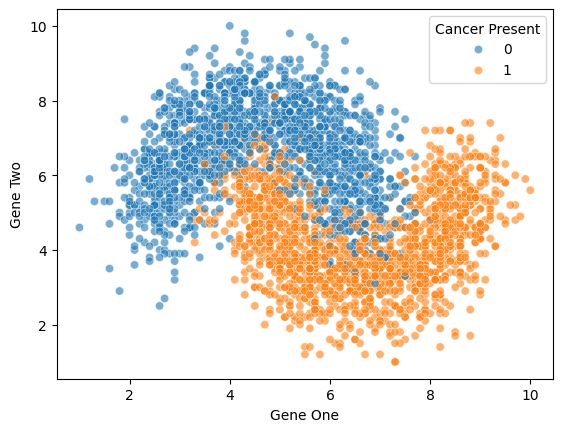

In [55]:
sns.scatterplot(data=df, x='Gene One', y='Gene Two', hue="Cancer Present", alpha=0.6);

In [56]:
len(df)

3000

(4.0, 8.0)

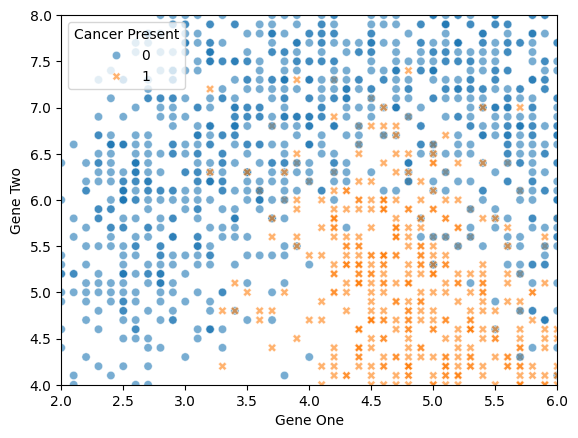

In [57]:
sns.scatterplot(data=df, x='Gene One', y='Gene Two', hue="Cancer Present", alpha=0.6, style='Cancer Present');
plt.xlim(2,6)
plt.ylim(4,8)

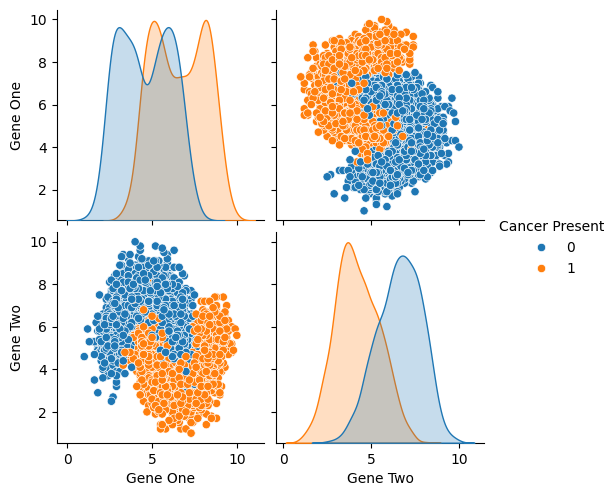

In [58]:
sns.pairplot(data=df, hue="Cancer Present");

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [60]:
X = df.drop('Cancer Present', axis=1)

In [61]:
y = df['Cancer Present']

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
...     X, y, test_size=0.3, random_state=42)

In [63]:
scaler = StandardScaler()

In [64]:
scaled_X_train = scaler.fit_transform(X_train)

In [65]:
scaled_X_test = scaler.transform(X_test)

In [66]:
from sklearn.neighbors import KNeighborsClassifier

In [67]:
# help(KNeighborsClassifier)

In [68]:
knn_model = KNeighborsClassifier(n_neighbors=1)

In [69]:
knn_model.fit(scaled_X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

In [70]:
y_pred = knn_model.predict(scaled_X_test)

In [71]:
from sklearn.metrics import confusion_matrix, classification_report

In [72]:
confusion_matrix(y_test, y_pred)

array([[422,  48],
       [ 50, 380]])

In [73]:
len(y_test)

900

In [74]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.90      0.90       470
           1       0.89      0.88      0.89       430

    accuracy                           0.89       900
   macro avg       0.89      0.89      0.89       900
weighted avg       0.89      0.89      0.89       900



In [75]:
df['Cancer Present'].value_counts()

Cancer Present
1    1500
0    1500
Name: count, dtype: int64

In [76]:
from sklearn.metrics import accuracy_score

In [77]:
accuracy_score(y_test, y_pred)

0.8911111111111111

In [78]:
test_error_rates = []

for k in range(1,30):
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(scaled_X_train, y_train)

    y_pred_test=knn_model.predict(scaled_X_test)
    test_error = 1- accuracy_score(y_test, y_pred)
    test_error_rates.append(test_error)
    

In [79]:
test_error_rates

[0.10888888888888892,
 0.10888888888888892,
 0.10888888888888892,
 0.10888888888888892,
 0.10888888888888892,
 0.10888888888888892,
 0.10888888888888892,
 0.10888888888888892,
 0.10888888888888892,
 0.10888888888888892,
 0.10888888888888892,
 0.10888888888888892,
 0.10888888888888892,
 0.10888888888888892,
 0.10888888888888892,
 0.10888888888888892,
 0.10888888888888892,
 0.10888888888888892,
 0.10888888888888892,
 0.10888888888888892,
 0.10888888888888892,
 0.10888888888888892,
 0.10888888888888892,
 0.10888888888888892,
 0.10888888888888892,
 0.10888888888888892,
 0.10888888888888892,
 0.10888888888888892,
 0.10888888888888892]

(0.0, 0.11)

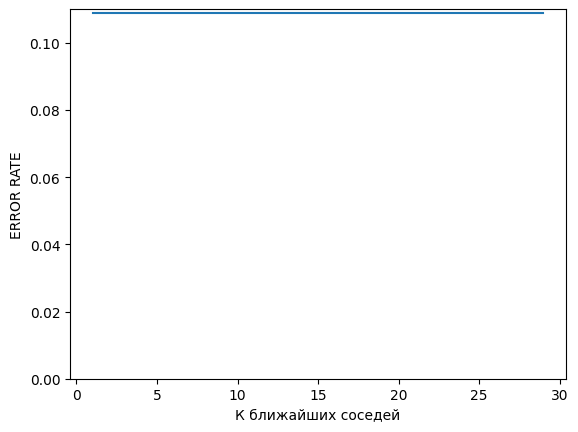

In [80]:
plt.plot(range(1, 30), test_error_rates)
plt.ylabel('ERROR RATE')
plt.xlabel('К ближайших соседей')
plt.ylim(0,0.11)

In [81]:
## PIPELINE -> GRIDSEARCH CV

In [ ]:
scaler = StandardScaler()

In [84]:
knn = KNeighborsClassifier()

In [85]:
knn.get_params().keys()

dict_keys(['algorithm', 'leaf_size', 'metric', 'metric_params', 'n_jobs', 'n_neighbors', 'p', 'weights'])

In [ ]:
operations = [(''scaler)]